In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [4]:
data=pd.read_csv('/content/LoanApprovalPrediction.csv')

In [9]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2.0,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y


In [5]:
data.describe()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,586.000000,598.000000,598.000000,577.000000,584.000000,549.000000
mean,0.755973,5292.252508,1631.499866,144.968804,341.917808,0.843352
std,1.007751,5807.265364,2953.315785,82.704182,65.205994,0.363800
min,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,0.000000,2877.500000,0.000000,100.000000,360.000000,1.000000
50%,0.000000,3806.000000,1211.500000,127.000000,360.000000,1.000000
75%,1.750000,5746.000000,2324.000000,167.000000,360.000000,1.000000
max,3.000000,81000.000000,41667.000000,650.000000,480.000000,1.000000


In [6]:
data.isnull().sum()


,0
Loan_ID,0
Gender,0
Married,0
Dependents,12
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,21
Loan_Amount_Term,14


In [7]:
data=data.dropna()

In [8]:
data.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [15]:
data.replace({'Loan_Status':{'N':0,'Y':1}},inplace=True)

/tmp/ipykernel_19832/3631174989.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({'Loan_Status':{'N':0,'Y':1}},inplace=True)


In [16]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
5,LP001011,Male,Yes,2.0,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


In [17]:
data['Dependents'].value_counts()

,count
Dependents,
0.0,289
2.0,90
1.0,84
3.0,42


<Axes: xlabel='Education', ylabel='count'>

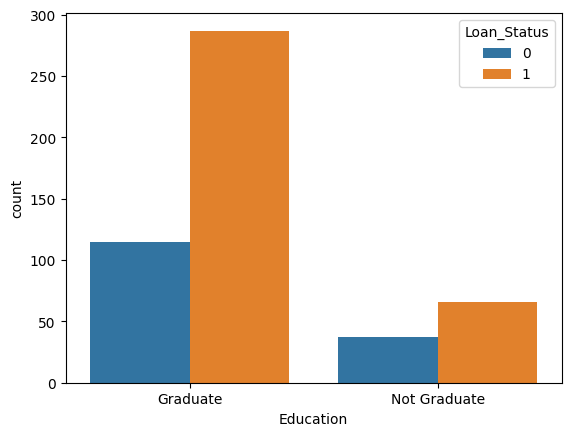

In [21]:
sns.countplot(x='Education', hue='Loan_Status', data=data)

<Axes: xlabel='Married', ylabel='count'>

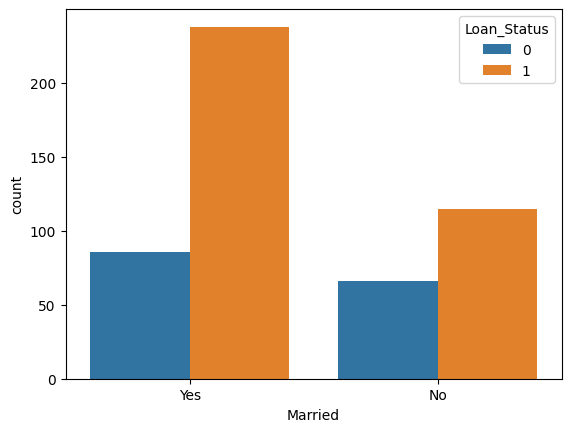

In [22]:
sns.countplot(x='Married', hue='Loan_Status', data=data)

In [34]:
data.replace({'Married':{'No':0,'Yes':1},'Gender':{'Male':1,'Female':0},'Self_Employed':{'No':0,'Yes':1},'Property_Area':{'Rural':0,'Semiurban':1,'Urban':2},'Education':{'Graduate':1,'Not Graduate':0}}, inplace=True)

/tmp/ipykernel_19832/818218614.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({'Married':{'No':0,'Yes':1},'Gender':{'Male':1,'Female':0},'Self_Employed':{'No':0,'Yes':1},'Property_Area':{'Rural':0,'Semiurban':1,'Urban':2},'Education':{'Graduate':1,'Not Graduate':0}}, inplace=True)


In [32]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1.0,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0.0,1,1,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,1,1,0.0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,1,0,0.0,1,0,6000,0.0,141.0,360.0,1.0,Urban,1
5,LP001011,1,1,2.0,1,1,5417,4196.0,267.0,360.0,1.0,Urban,1


In [35]:
data.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
593,LP002978,0,0,0.0,1,0,2900,0.0,71.0,360.0,1.0,0,1
594,LP002979,1,1,3.0,1,0,4106,0.0,40.0,180.0,1.0,0,1
595,LP002983,1,1,1.0,1,0,8072,240.0,253.0,360.0,1.0,2,1
596,LP002984,1,1,2.0,1,0,7583,0.0,187.0,360.0,1.0,2,1
597,LP002990,0,0,0.0,1,1,4583,0.0,133.0,360.0,0.0,1,0


In [36]:
X=data.drop(columns=['Loan_ID','Loan_Status'],axis=1)
Y=data['Loan_Status']

In [42]:
Xtrain,Xtest,Ytrain,Ytest=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=2)

In [43]:
print(X.shape,Xtrain.shape,Xtest.shape)

(505, 11) (404, 11) (101, 11)


In [44]:
classifier=svm.SVC(kernel='linear')

In [45]:
classifier.fit(Xtrain,Ytrain)

SVC(kernel='linear')

In [46]:
Xtrain_prediction=classifier.predict(Xtrain)
training_data_accuracy=accuracy_score(Xtrain_prediction,Ytrain)
print('Accuracy on training data : ',training_data_accuracy)
Xtest_prediction=classifier.predict(Xtest)
test_data_accuracy=accuracy_score(Xtest_prediction,Ytest)
print('Accuracy on test data : ',test_data_accuracy)

Accuracy on training data :  0.7970297029702971
Accuracy on test data :  0.801980198019802


In [48]:
inputdata=(1,1,2,1,1,5417,4196,267,360,1,2)
array=np.asarray(inputdata)
input_data_reshaped=array.reshape(1,-1)
prediction=classifier.predict(input_data_reshaped)
print(prediction)
if(prediction[0]==0):
  print('You do not get Loan approval')
else:
  print('You will get Loan')

[1]
You will get Loan


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
